In [8]:
# ============================================================
# CELL 1: KERAKLI KUTUBXONALAR
# ============================================================
# Bu kutubxonalar Kaggle notebook'da odatda OLDINDAN o'rnatilgan bo'ladi,
# shuning uchun pip install kerak emas, faqat import qilamiz.

import os          # papka/fayl yo'llari bilan ishlash uchun
import json        # annotatsiya JSON faylini o'qish uchun
import random      # tasodifiy tanlov (background patch joylarini tanlashda) uchun
import cv2         # OpenCV - rasm o'qish, kesish, o'lchamini o'zgartirish uchun
import numpy as np # rasm piksellarini massiv (array) ko'rinishida boshqarish uchun
import pandas as pd        # DataFrame - jadval ko'rinishidagi ma'lumotlar uchun
import matplotlib.pyplot as plt  # grafik va rasm ko'rsatish uchun
print("tugadi")

tugadi


In [9]:
print("=== /kaggle/input ichidagi datasetlar ===")
for item in os.listdir('/kaggle/input'):
    print(item)

=== /kaggle/input ichidagi datasetlar ===
datasets


In [10]:
# ============================================================
# CELL 2: KAGGLE'GA ULANGAN DATASETLARNI TEKSHIRISH
# ============================================================
# Bu CELL faqat KO'RISH uchun - hech narsa o'zgartirmaydi.
# Maqsad: /kaggle/input ichida real qanday papka nomlari borligini bilish,
# chunki har xil odam yuklagan datasetning nomi bir-biridan farq qilishi mumkin.

print("=== /kaggle/input ichidagi datasetlar ===")
for item in os.listdir('/kaggle/input'):
    print(item)

# MUHIM: agar shu yerda hech narsa chiqmasa (bo'sh ro'yxat), demak siz hali
# "+ Add Input" orqali hech qanday dataset qo'shmagansiz. Avval shuni qiling,
# keyin shu CELL'ni qayta ishga tushiring va chiqqan nomlarni keyingi
# CELL'lardagi yo'llarga moslang

=== /kaggle/input ichidagi datasetlar ===
datasets


In [11]:
# ============================================================
# CELL 3: WIDER FACE / FACES4COCO ANNOTATSIYASINI O'QISH FUNKSIYASI
# ============================================================
# Bu funksiya faces4coco JSON faylini o'qib, ichidan FAQAT
# "person" va "face" kategoriyalariga tegishli bounding box'larni
# ajratib oladi (boshqa kategoriyalar bo'lsa, ular e'tiborga olinmaydi).

def build_faces4coco_df(annotation_json_path, images_root):
    """
    annotation_json_path : faces4coco JSON faylining to'liq yo'li
    images_root           : COCO rasmlari joylashgan papka (train2017)

    Qaytaradi: DataFrame ustunlari -> image_path, x, y, w, h, label_name, label
    """
    # JSON faylni ochib o'qiymiz
    with open(annotation_json_path, 'r') as f:
        coco = json.load(f)

    # category_id -> kategoriya nomi ("person"/"face") lug'atini tuzamiz
    # Masalan: {1: "person", 2: "face"}
    catid_to_name = {cat['id']: cat['name'] for cat in coco['categories']}
    print("Mavjud kategoriyalar:", catid_to_name)

    # image_id -> fayl nomi lug'atini tuzamiz (annotatsiyada faqat ID bor,
    # haqiqiy fayl nomini topish uchun shu lug'at kerak)
    id_to_filename = {img['id']: img['file_name'] for img in coco['images']}

    rows = []  # natijadagi har bir qatorni shu ro'yxatga yig'amiz

    # Har bir annotatsiya yozuvini (bitta bounding box) ko'rib chiqamiz
    for ann in coco['annotations']:
        cat_name = catid_to_name.get(ann['category_id'], 'unknown')

        # Faqat "person" va "face" kerak, boshqasi bo'lsa o'tkazib yuboramiz
        if cat_name not in ('person', 'face'):
            continue

        img_id = ann['image_id']
        filename = id_to_filename.get(img_id)

        # Agar shu image_id ga mos fayl nomi topilmasa, o'tkazib yuboramiz
        if filename is None:
            continue

        # COCO formatdagi bbox: [x_min, y_min, width, height]
        x, y, w, h = ann['bbox']

        rows.append({
            'image_path': os.path.join(images_root, filename),
            'x': float(x),
            'y': float(y),
            'w': float(w),
            'h': float(h),
            'label_name': cat_name,
            # label raqami: face=2, person=1 (background=0 keyinroq CELL 5'da qo'shiladi)
            'label': 2 if cat_name == 'face' else 1
        })

    return pd.DataFrame(rows)

In [22]:
# # ============================================================
# # AVTOMATIK QIDIRISH: cocoface_instances_train2017.json QAYERDA?
# # ============================================================
# # Bu kod butun /kaggle/input ichini aylanib, kerakli JSON faylni
# # avtomatik topib, uning ANIQ to'liq yo'lini ko'rsatadi.
# # Qo'lda qidirish shart emas.

# import os

# target_filename = 'cocoface_instances_train2017.json'
# found_paths = []

# for root, dirs, files in os.walk('/kaggle/input'):
#     if target_filename in files:
#         full_path = os.path.join(root, target_filename)
#         found_paths.append(full_path)

# print(f"'{target_filename}' qidirildi...")
# print(f"Topilgan joylar soni: {len(found_paths)}")
# print()

# if found_paths:
#     for p in found_paths:
#         print(f"TOPILDI: {p}")
# else:
#     print("HECH QAYERDA TOPILMADI!")
#     print("Demak faces4coco-annotations dataset hali ulanmagan bo'lishi mumkin.")

# print()
# print("=" * 60)
# print("Xuddi shu tarzda val2017 faylini ham qidiramiz:")
# print("=" * 60)

# target_val = 'cocoface_instances_val2017.json'
# found_val = []

# for root, dirs, files in os.walk('/kaggle/input'):
#     if target_val in files:
#         found_val.append(os.path.join(root, target_val))

# for p in found_val:
#     print(f"TOPILDI: {p}")

In [23]:
# ============================================================
# CELL 4 (YAKUNIY - AVTOMATIK QIDIRISH ORQALI TASDIQLANGAN)
# ============================================================
ANNOTATION_JSON_TRAIN = '/kaggle/input/datasets/sherjahongir/faces4coco-annotations/cocoface_instances_train2017.json'
ANNOTATION_JSON_VAL   = '/kaggle/input/datasets/sherjahongir/faces4coco-annotations/cocoface_instances_val2017.json'

IMAGES_ROOT_TRAIN = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017'
IMAGES_ROOT_VAL   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017'

print("Tekshirish:")
print(f"  Train JSON mavjud: {os.path.exists(ANNOTATION_JSON_TRAIN)}")
print(f"  Val JSON mavjud:   {os.path.exists(ANNOTATION_JSON_VAL)}")
print(f"  Train rasmlar papkasi mavjud: {os.path.exists(IMAGES_ROOT_TRAIN)}")
print(f"  Val rasmlar papkasi mavjud:   {os.path.exists(IMAGES_ROOT_VAL)}")
print()

train_part_df = build_faces4coco_df(ANNOTATION_JSON_TRAIN, IMAGES_ROOT_TRAIN)
print(f"Train qismidan: {len(train_part_df)} qator")

val_part_df = build_faces4coco_df(ANNOTATION_JSON_VAL, IMAGES_ROOT_VAL)
print(f"Val qismidan: {len(val_part_df)} qator")

combined_df = pd.concat([train_part_df, val_part_df], ignore_index=True)

print(f"\nJami birlashtirilgan qatorlar: {len(combined_df)}")
print(combined_df['label_name'].value_counts())
print(f"Noyob rasmlar soni: {combined_df['image_path'].nunique()}")

combined_df.head(15)

Tekshirish:
  Train JSON mavjud: True
  Val JSON mavjud:   True
  Train rasmlar papkasi mavjud: True
  Val rasmlar papkasi mavjud:   True

Mavjud kategoriyalar: {1: 'person', 2: 'face'}
Train qismidan: 260614 qator
Mavjud kategoriyalar: {1: 'person', 2: 'face'}
Val qismidan: 10744 qator

Jami birlashtirilgan qatorlar: 271358
label_name
person    197871
face       73487
Name: count, dtype: int64
Noyob rasmlar soni: 61369


,image_path,x,y,w,h,label_name,label
0,/kaggle/input/datasets/awsaf49/coco-2017-datas...,339.880000,22.16000,153.880000,300.73000,person,1
1,/kaggle/input/datasets/awsaf49/coco-2017-datas...,471.640000,172.82000,35.920000,48.10000,person,1
2,/kaggle/input/datasets/awsaf49/coco-2017-datas...,382.480000,0.00000,256.800000,474.31000,person,1
3,/kaggle/input/datasets/awsaf49/coco-2017-datas...,40.650000,38.80000,418.380000,601.20000,person,1
4,/kaggle/input/datasets/awsaf49/coco-2017-datas...,0.000000,0.00000,198.920000,631.35000,person,1
5,/kaggle/input/datasets/awsaf49/coco-2017-datas...,170.364600,52.15086,88.061520,178.47345,face,2
6,/kaggle/input/datasets/awsaf49/coco-2017-datas...,2.870000,73.18000,143.500000,532.38000,person,1
7,/kaggle/input/datasets/awsaf49/coco-2017-datas...,105.200000,36.83000,112.060000,227.87000,person,1
8,/kaggle/input/datasets/awsaf49/coco-2017-datas...,84.030000,1.57000,110.940000,64.99000,person,1
9,/kaggle/input/datasets/awsaf49/coco-2017-datas...,27.330000,166.83000,319.280000,473.17000,person,1


In [24]:
# ============================================================
# YANGILANGAN: KICHIK BOUNDING BOXLARGA KO'PROQ E'TIBOR BERISH
# ============================================================
# Muammo: model asosan KATTA, YAQIN odamlarni yaxshi taniydi,
# chunki ular train datasetida ko'proq uchraydi (yaqin odam =
# katta bounding box = aniqroq patch).
#
# Yechim: combined_df'ni tahlil qilib, KICHIK bounding boxlar
# (uzoqdagi odamlar) sonini sun'iy ravishda OSHIRAMIZ - ular
# bir necha marta takrorlanadi, shunda model ularga ko'proq
# "e'tibor" beradi (bu "oversampling" deyiladi).

import numpy as np

# Har bir bounding box maydonini hisoblaymiz
combined_df['box_area'] = combined_df['w'] * combined_df['h']

# Maydonni 3 toifaga bo'lamiz: kichik, o'rta, katta
area_33 = combined_df['box_area'].quantile(0.33)
area_66 = combined_df['box_area'].quantile(0.66)

print(f"Kichik box chegarasi: < {area_33:.0f} piksel^2")
print(f"O'rta box chegarasi: {area_33:.0f} - {area_66:.0f}")
print(f"Katta box chegarasi: > {area_66:.0f}")

small_boxes = combined_df[combined_df['box_area'] < area_33]
medium_boxes = combined_df[(combined_df['box_area'] >= area_33) & (combined_df['box_area'] < area_66)]
large_boxes = combined_df[combined_df['box_area'] >= area_66]

print(f"\nKichik boxlar soni: {len(small_boxes)}")
print(f"O'rta boxlar soni: {len(medium_boxes)}")
print(f"Katta boxlar soni: {len(large_boxes)}")

# Kichik boxlarni 3 MARTA takrorlaymiz (oversampling) - shunda
# train paytida model ularni ko'proq "ko'radi" va ahamiyat beradi
small_boxes_oversampled = pd.concat([small_boxes] * 3, ignore_index=True)

# Hammasini birlashtiramiz
combined_df_balanced = pd.concat(
    [small_boxes_oversampled, medium_boxes, large_boxes],
    ignore_index=True
)

print(f"\nOversampling'dan KEYINGI jami qatorlar: {len(combined_df_balanced)}")
print(f"(Kichik boxlar endi {len(small_boxes_oversampled)} marta uchraydi, "
      f"jami datasetning {len(small_boxes_oversampled)/len(combined_df_balanced)*100:.1f}%)")

# combined_df o'rniga endi shu balanslangan versiyani ishlatamiz
combined_df = combined_df_balanced

Kichik box chegarasi: < 975 piksel^2
O'rta box chegarasi: 975 - 9195
Katta box chegarasi: > 9195

Kichik boxlar soni: 89548
O'rta boxlar soni: 89548
Katta boxlar soni: 92262

Oversampling'dan KEYINGI jami qatorlar: 450454
(Kichik boxlar endi 268644 marta uchraydi, jami datasetning 59.6%)


In [25]:
# ============================================================
# CELL 5: RASM FAYLLARI HAQIQATDA MAVJUDLIGINI TEKSHIRISH
# ============================================================
# Katta datasetda har bir faylni tekshirish juda sekin bo'lardi,
# shuning uchun faqat 200 tasini TASODIFIY tanlab tekshiramiz.
# Agar IMAGES_ROOT yo'li xato bo'lsa, bu yerda darrov ko'rinadi.

sample_check = combined_df.sample(min(200, len(combined_df)))
missing = [p for p in sample_check['image_path'].unique() if not os.path.exists(p)]

print(f"Tekshirilgan 200 tadan topilmagan rasm: {len(missing)}")
if missing:
    print("Misol yo'q fayl:", missing[0])
    print(">>> Agar barchasi yo'q chiqsa, IMAGES_ROOT yo'lini CELL 4'da qaytadan tekshiring")


Tekshirilgan 200 tadan topilmagan rasm: 0


In [26]:
# ============================================================
# CELL 6: BACKGROUND (FON) PATCHLARINI YASASH
# ============================================================
# CNN'ga faqat "bu yuz" va "bu tana" emas, balki "bu yerda HECH NARSA YO'Q"
# degan misollarni ham ko'rsatishimiz kerak, aks holda model har doim
# "bu yuz yoki tana" deb javob berishga moyil bo'lib qoladi.
# Shu funksiya har rasmdan, mavjud bounding boxlar bilan KESISHMAYDIGAN
# joylardan tasodifiy patch kesib oladi.

PATCH_SIZE = 64  # CNN'ga kiritiladigan patch o'lchami

def generate_background_patches(image_paths, existing_boxes_df, n_per_image=2, patch_size=PATCH_SIZE):
    """
    image_paths        : background patch yasaladigan rasmlar ro'yxati
    existing_boxes_df  : mavjud face/person bounding boxlari (kesishmaslik uchun)
    n_per_image         : har rasmdan necha ta background patch olish
    """
    rows = []

    for img_path in image_paths:
        # Fayl mavjudligini tekshiramiz (CELL 5'da aniqlangan xatolardan saqlanish uchun)
        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        H, W = img.shape[:2]
         # Shu rasmga tegishli barcha mavjud (face/person) bounding boxlarni olamiz
        boxes = existing_boxes_df[existing_boxes_df['image_path'] == img_path]

        attempts, collected = 0, 0
        # 20 marta urinib ko'ramiz, agar shuncha urinishda ham joy topilmasa, to'xtatamiz
        while collected < n_per_image and attempts < 20:
            attempts += 1

            # Agar rasm patch_size'dan kichik bo'lsa, tasodifiy joy tanlab bo'lmaydi
            if W <= patch_size or H <= patch_size:
                break

            # Tasodifiy chap-yuqori burchak koordinatasini tanlaymiz
            rx = random.randint(0, W - patch_size)
            ry = random.randint(0, H - patch_size)

            # Bu tasodifiy patch biror mavjud box bilan kesishib qolmasligini tekshiramiz
            overlap = False
            for _, b in boxes.iterrows():
                bx, by, bw, bh = b['x'], b['y'], b['w'], b['h']
                # Ikkita to'rtburchak kesishmasligi sharti (agar bu False bo'lsa, kesishadi)
                if not (rx + patch_size < bx or rx > bx + bw or
                        ry + patch_size < by or ry > by + bh):
                    overlap = True
                    break

            # Agar kesishish bo'lmasa - bu yaxshi "background" namuna, qo'shamiz
            if not overlap:
                rows.append({
                    'image_path': img_path,
                    'x': float(rx), 'y': float(ry),
                    'w': float(patch_size), 'h': float(patch_size),
                    'label_name': 'background',
                    'label': 0
                })
                collected += 1

    return pd.DataFrame(rows)

# RAM va vaqtni tejash uchun faqat 8000 ta rasmdan background olamiz
# (butun datasetdan emas - aks holda bu CELL juda uzoq ishlaydi)
unique_images = combined_df['image_path'].unique().tolist()
sample_images_for_bg = random.sample(unique_images, min(8000, len(unique_images)))

bg_df = generate_background_patches(sample_images_for_bg, combined_df, n_per_image=2)
print(f"Yasalgan background patch soni: {len(bg_df)}")

Yasalgan background patch soni: 14603


In [27]:
# ============================================================
# CELL 7: YAKUNIY final_df NI YASASH (bu CELL 8 uchun KERAK!)
# ============================================================
# Endi 3 turdagi ma'lumotni (face, person, background) BITTA jadvalga
# birlashtiramiz va tartibni ARALASHTIRAMIZ (aks holda model "avval
# hammasi face, keyin hammasi person" kabi tartibni yodlab qolishi mumkin).

final_df = pd.concat([combined_df, bg_df], ignore_index=True)

# frac=1 -> 100% qatorlarni aralashtirib qaytar (ya'ni butunlay shuffle)
# reset_index(drop=True) -> aralashtirilgandan keyin indexlarni 0,1,2... qilib tartiblaymiz
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== YAKUNIY DATASET TAQSIMOTI ===")
print(final_df['label_name'].value_counts())
print(f"\nJami qatorlar: {len(final_df)}")

# Keyinroq qayta ishlatish uchun diskka ham saqlab qo'yamiz (ixtiyoriy, lekin foydali)
final_df.to_csv('/kaggle/working/patch_dataset.csv', index=False)

# final_df endi tayyor - shundan keyin CELL 8 (final_df.sample(n=15000, ...))
# muammosiz ishlaydi, chunki final_df allaqachon mavjud bo'ladi
final_df.head(20)

=== YAKUNIY DATASET TAQSIMOTI ===
label_name
person        299893
face          150561
background     14603
Name: count, dtype: int64

Jami qatorlar: 465057


,image_path,x,y,w,h,label_name,label,box_area
0,/kaggle/input/datasets/awsaf49/coco-2017-datas...,264.857150,119.849550,92.415950,120.593690,face,2,11144.780425
1,/kaggle/input/datasets/awsaf49/coco-2017-datas...,71.831410,206.995770,6.488790,7.830710,face,2,50.811833
2,/kaggle/input/datasets/awsaf49/coco-2017-datas...,73.260000,0.720000,519.530000,241.940000,person,1,125695.088200
3,/kaggle/input/datasets/awsaf49/coco-2017-datas...,156.390000,231.530000,23.770000,27.000000,person,1,641.790000
4,/kaggle/input/datasets/awsaf49/coco-2017-datas...,623.300000,125.150000,16.280000,26.240000,person,1,427.187200
5,/kaggle/input/datasets/awsaf49/coco-2017-datas...,555.090000,187.020000,4.460000,11.080000,person,1,49.416800
6,/kaggle/input/datasets/awsaf49/coco-2017-datas...,171.034850,254.007540,69.804470,126.800600,face,2,8851.248679
7,/kaggle/input/datasets/awsaf49/coco-2017-datas...,202.650000,2.610000,98.430000,134.330000,person,1,13222.101900
8,/kaggle/input/datasets/awsaf49/coco-2017-datas...,438.800000,260.160000,8.380000,26.100000,person,1,218.718000
9,/kaggle/input/datasets/awsaf49/coco-2017-datas...,174.350000,472.700000,13.100000,27.740000,person,1,363.394000


In [28]:
# # ============================================================
# # CELL 8: DATASETNI KICHRAYTIRISH VA TRAIN/VAL GA BO'LISH
# # ============================================================

# # Butun final_df (yuz minglab qator) o'rniga, tezroq sinov uchun
# # faqat 15000 qatorli tasodifiy namuna olamiz.
# # random_state=42 -> har safar bir xil "tasodifiy" natija chiqishi uchun
# # (takrorlanuvchanlik, debug qilishni osonlashtiradi)
# final_df_small = final_df.sample(n=15000, random_state=42).reset_index(drop=True)

# # Tekshirib ko'ramiz: 15000 ta qatorda face/person/background nisbati qanday
# print("Kichik dataset taqsimoti:")
# print(final_df_small['label_name'].value_counts())

# from sklearn.model_selection import train_test_split

# Datasetni 2 qismga bo'lamiz:
#   train_df (80%) -> model shu orqali o'rganadi
#   val_df   (20%) -> model HECH QACHON shu orqali o'rganmaydi,
#                      faqat "haqiqatda qancha bilib oldi" deb TEKSHIRISH uchun
# stratify=label -> bo'lganda har 3 klass (0,1,2) ham train, ham val'da
#                    bir xil PROPORTSIYADA qolishini kafolatlaydi
#                    (aks holda val'da tasodifan faqat "face" chiqib qolishi mumkin)
# train_df, val_df = train_test_split(
#     final_df_small,
#     test_size=0.2,
#     random_state=42,
#     stratify=final_df_small['label']
# )

# print(f"\nTrain: {len(train_df)} qator | Validation: {len(val_df)} qator")





# ============================================================
# CELL 8 (YANGILANGAN): 300,000 QATORLI DATASETDA ISHLASH
# ============================================================
# Avvalgi eslatmaga ko'ra: 464,967 qatorlik to'liq (oversampling
# qilingan) datasetdan, vaqtni tejash uchun 300,000 qatorli
# tasodifiy namuna olamiz.

TARGET_SIZE = 300000

if len(final_df) > TARGET_SIZE:
    final_df_full = final_df.sample(n=TARGET_SIZE, random_state=42).reset_index(drop=True)
else:
    final_df_full = final_df.copy()

print("300,000 qatorli dataset taqsimoti:")
print(final_df_full['label_name'].value_counts())
print(f"Jami qatorlar: {len(final_df_full)}")

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    final_df_full,
    test_size=0.2,
    random_state=42,
    stratify=final_df_full['label']
)
print(f"\nTrain: {len(train_df)} qator | Validation: {len(val_df)} qator")


300,000 qatorli dataset taqsimoti:
label_name
person        193385
face           97184
background      9431
Name: count, dtype: int64
Jami qatorlar: 300000

Train: 240000 qator | Validation: 60000 qator


In [29]:
# ============================================================
# CELL 9 (YAKUNIY - HAMMASI BITTA CELL ICHIDA)
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import random

PATCH_SIZE = 64


class PatchDataset(Dataset):
    def __init__(self, dataframe, patch_size=PATCH_SIZE, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])

        if img is None:
            patch = np.zeros((self.patch_size, self.patch_size, 3), dtype=np.uint8)
        else:
            H, W = img.shape[:2]
            x, y, w, h = int(row['x']), int(row['y']), int(row['w']), int(row['h'])
            x, y = max(0, x), max(0, y)
            x2, y2 = min(W, x + w), min(H, y + h)

            if x2 <= x or y2 <= y:
                patch = np.zeros((self.patch_size, self.patch_size, 3), dtype=np.uint8)
            else:
                patch = img[y:y2, x:x2]
                patch = cv2.resize(patch, (self.patch_size, self.patch_size))

            patch = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)

        if self.augment and random.random() > 0.5:
            patch = np.fliplr(patch).copy()

        patch = patch.astype(np.float32) / 255.0
        patch = torch.from_numpy(patch).permute(2, 0, 1)

        label = int(row['label'])
        return patch, label


# ---- ENDI KLASS TAYYOR, SHU CELL ICHIDA DARROV ISHLATAMIZ ----

train_dataset = PatchDataset(train_df, augment=True)
val_dataset = PatchDataset(val_df, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train batch soni: {len(train_loader)} | Val batch soni: {len(val_loader)}")

Train batch soni: 7500 | Val batch soni: 1875


In [30]:
# ============================================================
# CELL 10: CNN ARXITEKTURASI (NOLDAN, TASODIFIY VAZNLAR BILAN)
# ============================================================

class SimpleCNN(nn.Module):
    """
    3 klassli classifier: 0=background, 1=person, 2=face
    Kirish o'lchami: (batch_size, 3 kanal, 64 piksel, 64 piksel)

    MUHIM: Bu yerdagi barcha qatlamlar (Conv2d, Linear) PyTorch tomonidan
    AVTOMATIK TASODIFIY raqamlar bilan boshlanadi (random initialization).
    Hech qanday tayyor (pretrained) vazn ishlatilmaydi -> bu FINE-TUNING EMAS,
    balki TO'LIQ NOLDAN TRAIN qilish.
    """

    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()

        # ---- 1-CONV BLOK ----
        # Conv2d(3, 16, ...) -> kirish 3 kanal (RGB), chiqish 16 "filtr xarita"
        # kernel_size=3 -> har filtr 3x3 piksel oynachani ko'radi
        # padding=1 -> chegaralarda piksel yo'qotmaslik uchun atrofga 1 qator qo'shadi
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # BatchNorm -> har batchdagi qiymatlarni normalizatsiya qiladi,
        # train barqarorroq va tezroq bo'lishiga yordam beradi
        self.bn1 = nn.BatchNorm2d(16)

        # ---- 2-CONV BLOK ----
        # Endi 16 kanaldan 32 kanalga o'tamiz - tarmoq chuqurlashgani sayin
        # ko'proq murakkab xususiyatlarni (shakl, tekstura) o'rganadi
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # ---- 3-CONV BLOK ----
        # 32 -> 64 kanal, eng yuqori darajadagi xususiyatlar (masalan
        # "ko'z+burun+og'iz birgalikda = yuz" kabi murakkab patternlar)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # MaxPool2d(2,2) -> rasm o'lchamini har safar 2 marta kichraytiradi
        # (64->32->16->8), bir xil pool barcha 3 blokda qayta ishlatiladi
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout(0.3) -> train paytida tasodifiy 30% neyronni "o'chirib qo'yadi"
        # Bu OVERFITTING'NING OLDINI OLADI (model faqat train datasetni
        # yodlab olib, yangi rasmda ishlamay qolishining oldini oladi)
        self.dropout = nn.Dropout(0.3)

        # ---- FULLY CONNECTED (KLASSIFIKATSIYA) QATLAMLARI ----
        # 3-blokdan keyin rasm o'lchami 8x8, kanal soni 64 -> jami 8*8*64=4096 son
        # Bu "flatten" qilingan vektor fc1 ga kiritiladi
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        # fc2 -> 128 dan 3 ga (3 klass: background/person/face uchun yakuniy ball)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # forward() -> ma'lumot model ichida qanday "oqishi"ni belgilaydi

        # Blok 1: Conv -> BatchNorm -> ReLU (aktivatsiya) -> Pool
        # ReLU -> manfiy qiymatlarni 0 ga tenglashtiradi, modelga
        # CHIZIQSIZLIK (nonlinearity) qo'shadi - shu bo'lmasa CNN faqat
        # chiziqli funksiya bo'lib qolardi va murakkab narsalarni o'rganolmasdi
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # natija: 32x32x16

        # Blok 2: xuddi shu mantiq, lekin chuqurroq
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # natija: 16x16x32

        # Blok 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # natija: 8x8x64

        # Flatten -> (batch, 64, 8, 8) shaklidagi 4D tensorni
        # (batch, 4096) shaklidagi 2D tensorga "yozib" tashlaymiz,
        # chunki Linear qatlam faqat 2D (batch, features) kutadi
        x = x.view(x.size(0), -1)

        # Dropout -> faqat train paytida ishlaydi (model.eval() da avtomatik o'chadi)
        x = self.dropout(x)

        # fc1 + ReLU -> 4096 ta sondan 128 ta "yashirin" xususiyat chiqaradi
        x = F.relu(self.fc1(x))

        # fc2 -> yakuniy 3 ta raqam (har klass uchun "ball"/logit)
        # E'TIBOR: bu yerda softmax QO'LLANMAYDI, chunki CrossEntropyLoss
        # ichida softmax avtomatik hisoblanadi (qo'shimcha qo'yish xato bo'lardi)
        x = self.fc2(x)
        return x


In [31]:

# GPU mavjud bo'lsa undan foydalanamiz (tezroq), aks holda CPU (sekinroq)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Ishlatiladigan qurilma: {device}")

# Modelni yaratamiz va GPU/CPU xotirasiga ko'chiramiz
model = SimpleCNN(num_classes=3).to(device)
print(model)

Ishlatiladigan qurilma: cuda
SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [32]:
# ============================================================
# CELL 11: TRAIN VA VALIDATE FUNKSIYALARI
# ============================================================

import time

# CrossEntropyLoss -> ko'p klassli klassifikatsiya uchun standart loss funksiyasi.
# U ichida avtomatik softmax qo'llaydi va modelning noto'g'ri bashoratiga
# qarab "qancha xato qildi" degan yagona songa (loss) aylantiradi
criterion = nn.CrossEntropyLoss()

# Adam optimizer -> vaznlarni yangilash algoritmi.
# lr=0.001 (learning rate) -> har qadamda vaznlar qancha "katta" o'zgarishi.
# Juda katta bo'lsa model "sapchiydi" (yaqinlashmaydi), juda kichik bo'lsa juda sekin o'rganadi
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Butun train datasetni BIR MARTA to'liq ko'rib chiqish = 1 epoch.
    Bu funksiya har chaqirilganda modelning vaznlarini YANGILAYDI.
    """
    model.train()  # modelni "train rejimi"ga o'tkazadi (Dropout, BatchNorm ishlaydi)
    total_loss, correct, total = 0, 0, 0

    # loader avtomatik ravishda 32talab (batch_size) patch va label beradi
    for patches, labels in loader:
        # Ma'lumotlarni GPU/CPU ga ko'chiramiz (model qaysi qurilmada bo'lsa, shu yerda)
        patches, labels = patches.to(device), labels.to(device)

        # Oldingi qadamdan qolgan gradientlarni tozalaymiz
        # (aks holda gradientlar to'planib, noto'g'ri natija berardi)
        optimizer.zero_grad()

        # FORWARD PASS: model patchlarni ko'rib, bashorat (outputs) chiqaradi
        outputs = model(patches)

        # Bashorat bilan haqiqiy labelni solishtirib, xato darajasini (loss) hisoblaymiz
        loss = criterion(outputs, labels)

        # BACKWARD PASS: loss'dan har bir vaznga "qancha hissa qo'shganini"
        # hisoblab chiqaradi (gradient hisoblash, zanjir qoidasi/chain rule orqali)
        loss.backward()

        # Hisoblangan gradientlar asosida vaznlarni biroz YAXSHIROQ tomonga suradi
        optimizer.step()

        # ---- Statistikani yig'ish (faqat kuzatish uchun, trainga ta'sir qilmaydi) ----
        total_loss += loss.item() * patches.size(0)
        _, predicted = torch.max(outputs, 1)  # eng yuqori balli klassni tanlaymiz
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # O'rtacha loss va accuracy qaytaramiz
    return total_loss / total, correct / total


In [33]:
def validate(model, loader, criterion, device):
    """
    Validation dataset ustida tekshirish.
    MUHIM FARQ train_one_epoch'dan: bu yerda vaznlar O'ZGARMAYDI
    (optimizer.step() yo'q), faqat "model qanday ishlayotganini" o'lchaymiz.
    """
    model.eval()  # "baholash rejimi" - Dropout o'chadi, BatchNorm "saqlangan" statistikani ishlatadi
    total_loss, correct, total = 0, 0, 0

    # torch.no_grad() -> gradient hisoblanmaydi, bu tezroq va kam xotira ishlatadi
    # (chunki bizga backward() kerak emas, faqat forward natija kerak)
    with torch.no_grad():
        for patches, labels in loader:
            patches, labels = patches.to(device), labels.to(device)
            outputs = model(patches)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * patches.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [34]:
# # ============================================================
# # CELL 12 (YANGILANGAN): TO'LIQ DATASETDA TRAIN - EPOCH KAMAYTIRILGAN
# # ============================================================
# # To'liq dataset (271,358 qator) uchun, bitta epoch ~10-15 daqiqa oladi.
# # 6 epoch -> taxminan 1-1.5 soat. Bu Kaggle 9-soatlik limitiga mos.

# NUM_EPOCHS = 6
# history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# for epoch in range(NUM_EPOCHS):
#     start = time.time()

#     train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
#     val_loss, val_acc = validate(model, val_loader, criterion, device)

#     history['train_loss'].append(train_loss)
#     history['train_acc'].append(train_acc)
#     history['val_loss'].append(val_loss)
#     history['val_acc'].append(val_acc)

#     elapsed = time.time() - start
#     print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
#           f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
#           f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | "
#           f"{elapsed:.1f}s ({elapsed/60:.1f} daqiqa)")









# ============================================================
# CELL 12 (YANGILANGAN): EPOCH SONI OSHIRILDI
# ============================================================
# Oversampling tufayli dataset endi biroz kattaroq (kichik boxlar
# 3 marta takrorlangan), va model kichik/uzoq odamlarni yaxshiroq
# o'rganishi uchun ko'proq epoch kerak.

# ============================================================
# CELL 12 (YANGILANGAN): EPOCH SONI = 9
# ============================================================
NUM_EPOCHS = 9

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | "
          f"{elapsed:.1f}s ({elapsed/60:.1f} daqiqa)")


Epoch 1/9 | Train Loss: 0.2153 Acc: 0.921 | Val Loss: 0.1959 Acc: 0.928 | 828.4s (13.8 daqiqa)
Epoch 2/9 | Train Loss: 0.1465 Acc: 0.946 | Val Loss: 0.1287 Acc: 0.954 | 823.0s (13.7 daqiqa)
Epoch 3/9 | Train Loss: 0.1262 Acc: 0.954 | Val Loss: 0.1198 Acc: 0.956 | 825.2s (13.8 daqiqa)
Epoch 4/9 | Train Loss: 0.1139 Acc: 0.959 | Val Loss: 0.1021 Acc: 0.963 | 841.2s (14.0 daqiqa)
Epoch 5/9 | Train Loss: 0.1065 Acc: 0.962 | Val Loss: 0.1115 Acc: 0.960 | 819.1s (13.7 daqiqa)
Epoch 6/9 | Train Loss: 0.0987 Acc: 0.964 | Val Loss: 0.1036 Acc: 0.963 | 801.9s (13.4 daqiqa)
Epoch 7/9 | Train Loss: 0.0937 Acc: 0.966 | Val Loss: 0.0964 Acc: 0.966 | 817.5s (13.6 daqiqa)
Epoch 8/9 | Train Loss: 0.0884 Acc: 0.968 | Val Loss: 0.0880 Acc: 0.969 | 829.8s (13.8 daqiqa)
Epoch 9/9 | Train Loss: 0.0845 Acc: 0.969 | Val Loss: 0.0899 Acc: 0.968 | 836.3s (13.9 daqiqa)


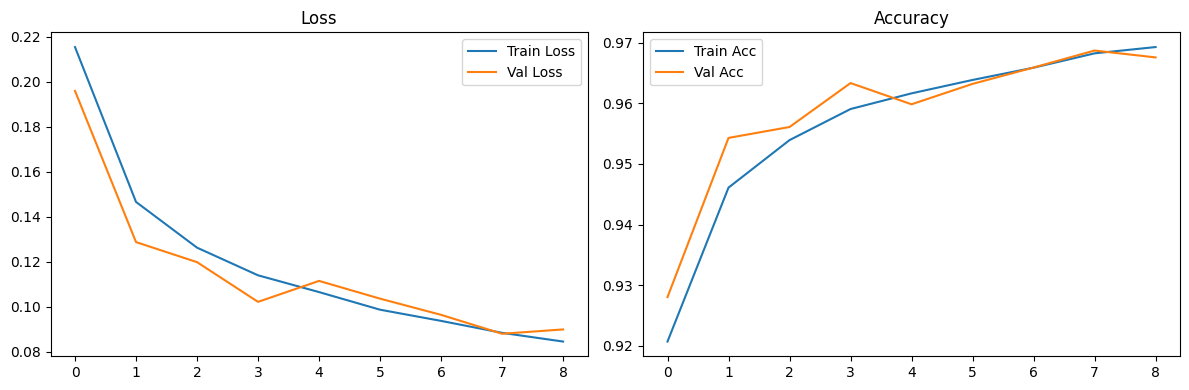

In [39]:
# ============================================================
# CELL 13: NATIJANI GRAFIK QILIB KO'RISH
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chap grafik: Loss (xato darajasi) - PASAYISHI kerak
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

# O'ng grafik: Accuracy (to'g'rilik) - OSHISHI kerak
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 14: TRAIN QILINGAN MODELNI SAQLASH
# ============================================================

# state_dict() -> modelning BARCHA o'rgangan vaznlarini (raqamlarini) lug'at
# (dictionary) ko'rinishida qaytaradi. Bu .pth fayl sifatida diskka yoziladi.
torch.save(model.state_dict(), '/kaggle/working/simple_cnn_face.pth')
print("Model saqlandi: /kaggle/working/simple_cnn_face.pth")

# KEYINGI SAFAR shu modelni qayta ishlatish uchun:
#   model = SimpleCNN(num_classes=3)
#   model.load_state_dict(torch.load('/kaggle/working/simple_cnn_face_person.pth'))
#   model.eval()


Model saqlandi: /kaggle/working/simple_cnn_face.pth
